<a href="https://colab.research.google.com/github/sankalp120/cv_satellitelanduse/blob/main/cv_satproject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install torch torchvision scikit-learn

In [ ]:
!pip install torchvision

In [ ]:
from torchvision.datasets import EuroSAT
from torchvision import transforms
from torch.utils.data import DataLoader, random_split

transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
])

dataset = EuroSAT(
    root="./data",
    download=True,
    transform=transform
)

train_size = int(0.8 * len(dataset))
test_size  = len(dataset) - train_size

train_data, test_data = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_data, batch_size=32)

print("Classes:", dataset.classes)
print("Total images:", len(dataset))

100%|██████████| 94.3M/94.3M [00:02<00:00, 42.9MB/s]


Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Total images: 27000


In [ ]:
import torch
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.mobilenet_v2(weights="IMAGENET1K_V1")
model.classifier[1] = nn.Linear(model.last_channel, len(dataset.classes))

model = model.to(device)

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 234MB/s]


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [9]:
epochs = 10

for epoch in range(epochs):
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_acc = 100 * correct / total
    print(f"Epoch {epoch+1}/{epochs} | Loss: {running_loss/len(train_loader):.4f} | Train Acc: {train_acc:.2f}%")

Epoch 1/10 | Loss: 0.3748 | Train Acc: 88.03%
Epoch 2/10 | Loss: 0.2241 | Train Acc: 92.96%
Epoch 3/10 | Loss: 0.1795 | Train Acc: 94.32%
Epoch 4/10 | Loss: 0.1566 | Train Acc: 94.75%
Epoch 5/10 | Loss: 0.1377 | Train Acc: 95.43%
Epoch 6/10 | Loss: 0.1400 | Train Acc: 95.44%
Epoch 7/10 | Loss: 0.1184 | Train Acc: 96.15%
Epoch 8/10 | Loss: 0.1025 | Train Acc: 96.60%
Epoch 9/10 | Loss: 0.0959 | Train Acc: 96.87%
Epoch 10/10 | Loss: 0.1031 | Train Acc: 96.67%


In [10]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print("Test Accuracy:", 100 * correct / total)

Test Accuracy: 97.01851851851852


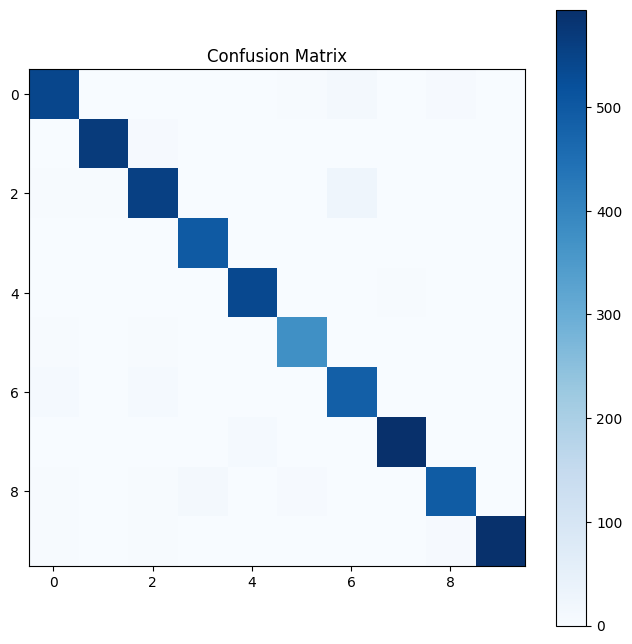

In [11]:
from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,8))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()
plt.show()